---
title: Your first quantum experiment
description: Use Qiskit to calculate the energy of a two-spin Ising system.
---

{/* cspell:ignore  */}



# Your first quantum experiment

## Introduction

In the following video, Olivia Lanes steps you through the content in this lesson. Alternatively, you can open the [YouTube video](https://youtu.be/kniiVC538nY?si=13OJnaO5jyAUmoPQ) for this lesson in a separate window.

<IBMVideo id="134786191" title="In this video Olivia walks you through finding the energy of a two-qubit Ising Hamiltonian using the Estimator primitive in Qiskit." />

By now, you've run your first quantum circuit and learned the basics of quantum computing: how quantum states are represented, how gates act on those states, and how quantum features like superposition and entanglement are involved. Now it's time to put all of this into practice and solve your first problem on a quantum computer.

We'll explore the broader landscape of quantum-suitable problems in a later lesson. For now, we'll focus on a problem in the domain of nature simulation: using a quantum computer as a cleaner, more controllable stand-in for a natural quantum system. In fact, this was the first application Richard Feynman envisioned for quantum computers in the 1980s. As he famously put it: "Nature isn't classical, dammit, and if you want to make a simulation of nature, you'd better make it quantum mechanical..."

In this lesson, we'll follow that principle to simulate the interaction between two spins, which you can think of as tiny magnets. Depending on the sign of their interaction, they might prefer to align and point in the same direction, or anti-align and point in opposite directions. We'll focus on the latter case because it often leads to more interesting — and more challenging — behavior. Once we understand this small two-qubit system, we'll show how the same ideas scale up, allowing quantum computers to take advantage of their exponential scaling when simulating large spin systems.

## Two interacting magnets

For this problem, we're going to use two qubits, one for each spin in our model. Each spin can be pointing up (qubit state $|0\rangle$), down (qubit state $|1\rangle$), or in a superposition of the two states.

If the spins have an *antiferromagnetic* interaction, it means they want to anti-align, so when one is up, the other wants to be down, and vice-versa.

Now suppose there is also a magnetic field pointing from left to right in our system. Because this field points across the usual up-down direction of the spins, it is called a transverse field. This field can flip spins, which causes the lowest energy configuration to be a specific superposition of up-and-down spin arrangements rather than any single definite spin pattern.

We can describe all of these effects using a mathematical object called a Hamiltonian. The Hamiltonian tells us the energy of the system for a given arrangement of spins:

$$
H = J Z_1 Z_0 + h_x (X_1 + X_0)
$$

where $J$ is a coefficient controlling the strength of the interaction between spins and $h_x$ is a coefficient for the strength of the external magnetic field. $Z_1 Z_0$ rewards or penalizes the spins depending on whether they are aligned or anti-aligned, and $X_0$ and $X_1$ represent the spin-flipping effect of the magnetic field.

In physics, systems tend to settle into the state with the lowest possible energy, called the ground state. Finding this lowest-energy state is a common problem, but it requires optimization techniques that are beyond the scope of this lesson.

Instead, we will ask a simpler question: If we prepare the spins in a particular state, what is the energy of that state?

To answer this, we will:

1. Prepare the spins in a state of our choosing
2. Measure the energy of that state using the Hamiltonian above

This is exactly the kind of calculation that appears inside larger quantum algorithms, such as variational algorithms, which you can explore in later courses.

## Qiskit implementation

Before jumping into writing code, we need a bit of context setting. When we run a quantum circuit, we always end by measuring the qubits. But there are two different kinds of questions we might want to ask about the result of that measurement: Sometimes, we just want to know what the state of the qubit is. Other times, we want to know, given the quantum state, what is the value of a physical quantity, like energy?

In Qiskit, these two types of questions are handled by two different tools, called primitives.

`Sampler` answers the first kind of question. It runs the circuit many times and tells us how often we measure each possible outcome, like `00`, `01`, `10`, or `11`. The result is a histogram that shows the probability of each measurement outcome.

`Estimator` answers the second kind of question. Instead of giving us a histogram, it combines many measurements behind the scenes to compute a single number, such as the energy of the state according to a Hamiltonian we provide.

To help you understand when and why we would use each of these tools, we'll walk through two complete workflows (called "Qiskit patterns") applied to the same two-qubit system.

#### Qiskit patterns workflow

The Qiskit patterns workflow is a general framework we use to solve quantum problems with Qiskit. It breaks a quantum computing task into four steps:

1. Map the problem to a model that can be represented by quantum circuits
2. Optimize the circuit to be run on a specific backend
3. Execute the optimized circuit on the selected backend
4. Post-process the raw measurement data

### Experiment 1: Use `Sampler` to measure the state

#### Map

In general, the mapping step is where we figure out how to represent a real-world problem in terms of qubits, operators, and measurements. In many applications, this is the trickiest and most involved part of the workflow — even simple questions, like "what does each qubit represent?" do not always have straightforward answers.

In this experiment, however, the mapping is deliberately simple. Each physical degree of freedom maps directly onto a single qubit. Because of this one-to-one correspondence, the mapping step reduces to choosing the quantum state we want to prepare and writing a circuit that prepares and measures that state.

Here, we'll prepare an entangled Bell state, similar to the one we made in the very first lesson of this course:

$$
\vert\Psi\rangle = \frac{1}{\sqrt{2}}(\vert 10\rangle - \vert 01\rangle)
$$



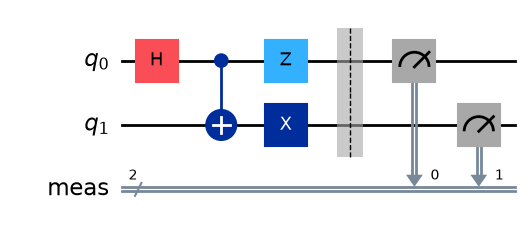

In [1]:
# Import Qiskit primitives
from qiskit import QuantumCircuit

# Make state
qc = QuantumCircuit(2)
qc.h(0)
qc.cx(0, 1)
qc.x(1)
qc.z(0)

# Measure state
qc.measure_all()

# Draw circuit
qc.draw("mpl")

#### Optimize

Before we run our circuit on a quantum computer (or a simulator if you have exhausted your free time on real quantum computers for the month), we need to prepare it for execution. This step is called optimization. (Note: this use of the word "optimization" can be confusing. In quantum computing, optimization problems refer to a specific class of problems. Here, we're using optimization to describe a required preparation step that every quantum circuit goes through before it can be run efficiently on hardware.)

During optimization:

1. We choose the backend — either a real quantum computer or a simulator.
2. We assign our circuit's qubits to physical qubits on the device.
3. We rewrite the circuit using only the gates that the quantum computer can actually perform.
4. Optionally implement error mitigation and suppression techniques to reduce the effects of noise.

In Qiskit, this is handled automatically by the transpiler. Once you pick your backend, the transpiler does all the work to make your circuit ready for execution, so you don't have to manually adjust the gates or qubit assignments. The transpiler also offers different optimization levels, which can help reduce errors if needed. The optimization is done in stages called 'passes'. So this optimization will be handled by the `pass_manager` in the code below. To learn more about errors and error mitigation, see Olivia Lane's [Quantum Computing in Practice](/learning/courses/quantum-computing-in-practice) course.



In [2]:
# Load the Qiskit Runtime service
from qiskit_ibm_runtime import QiskitRuntimeService

## Load the Qiskit Runtime service
# QiskitRuntimeService.save_account(
#    channel="ibm_quantum_platform",
#    token="YOUR_TOKEN_HERE",
#    overwrite=True,
#    set_as_default=True,
# )
# service = QiskitRuntimeService(channel="ibm_quantum_platform")


# Or load saved credentials
service = QiskitRuntimeService()

# Use the least busy backend, or uncomment the loading of a specific backend like "ibm_brisbane".
backend = service.least_busy(operational=True, simulator=False, min_num_qubits=127)
# backend = service.backend("ibm_brisbane")
print(backend.name)

qiskit_runtime_service.__init__:WARNING:2026-07-21 13:11:34,174: Instance was not set at service instantiation. Free and trial plan instances will be prioritized. Based on the following filters: (tags: None, region: us-east, eu-de), and available plans: (open), the available account instances are: fadhelhdz-lab. If you need a specific instance set it explicitly either by using a saved account with a saved default instance or passing it in directly to QiskitRuntimeService(). Alternatively, pass instance='auto' or save it to your account for auto-selection without warning.
qiskit_runtime_service.backends:WARNING:2026-07-21 13:11:34,493: Loading instance: fadhelhdz-lab, plan: open
qiskit_runtime_service.backends:WARNING:2026-07-21 13:11:38,177: Using instance: fadhelhdz-lab, plan: open


ibm_fez


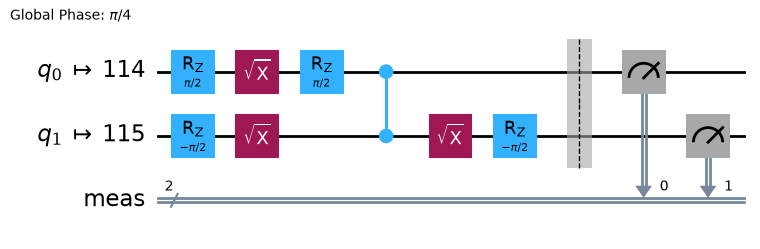

In [3]:
# Transpile the circuit and optimize for running on the quantum computer selected
# Step 2: Transpile
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager

target = backend.target
pm = generate_preset_pass_manager(target=target, optimization_level=3)
qc_isa = pm.run(qc)

qc_isa.draw("mpl")

#### Execute

Now we're ready to execute! We'll load Sampler, then send the job to the backend.



In [4]:
# Load the Runtime primitive and session
from qiskit_ibm_runtime import SamplerV2 as Sampler

sampler = Sampler(mode=backend)

Or, if you're using a simulator, you can uncomment and run this cell instead:



In [5]:
## Load the backend sampler
# from qiskit.primitives import BackendSamplerV2

## Load the Aer simulator and generate a noise model based on the currently-selected backend.
# from qiskit_aer import AerSimulator
# from qiskit_aer.noise import NoiseModel

# noise_model = NoiseModel.from_backend(backend)

## Define a simulator using Aer, and use it in Sampler.
# backend_sim = AerSimulator(noise_model=noise_model)
# sampler_sim = BackendSamplerV2(backend=backend_sim)

## Alternatively, load a fake backend with generic properties and define a simulator.
## backend_gen = GenericBackendV2(num_qubits=18)
## sampler_gen = BackendSamplerV2(backend=backend_gen)

In [6]:
job = sampler.run([qc_isa], shots=100)
# job = sampler_sim.run([qc_isa]) # uncomment if you want to run on a simulator
res = job.result()
counts = res[0].data.meas.get_counts()

#### Post-process



counts =  {'01': 46, '10': 52, '11': 2}


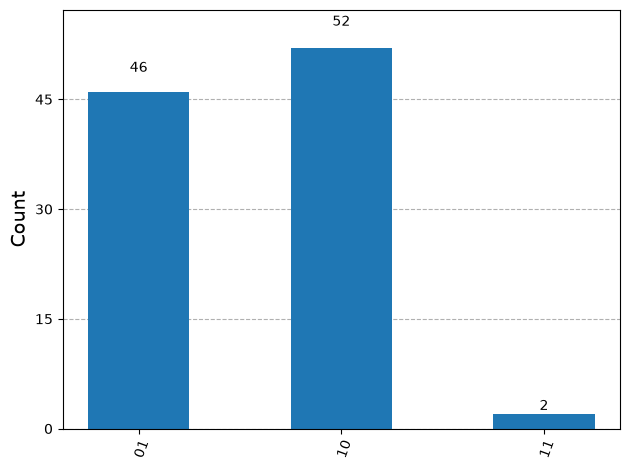

In [7]:
from qiskit.visualization import plot_histogram

print("counts = ", counts)
plot_histogram(counts)

We see that the majority of counts are in either `01` or `10`, meaning that when one qubit was measured to be `0`, the other was `1`, and vice-versa. This is consistent with the Bell state $\vert \Psi^- \rangle$ we prepared.

### Experiment 2: Use `Estimator` to measure the energy

Now that we've seen how to sample a quantum state, let's use Estimator to compute the energy of our Bell state $\vert \Psi^- \rangle = \frac{1}{\sqrt{2}}(\vert 01 \rangle - \vert 10 \rangle)$.

#### Map

As a reminder, the energy of the system is determined by the interaction between the spins ($J$) and the external magnetic field ($h_x$) as captured by the Hamiltonian:

$$
H = J Z_1 Z_0 + h_x (X_1 + X_0)
$$

Each term in the Hamiltonian tells us how a certain combination of spins contributes to the energy. In Qiskit, we can represent these terms as Pauli operators, which are just labels for simple actions on qubits:

* $Z_1 Z_0$ acts with a $Z$ on both qubits.
* $X_0$ acts with $X$ on qubit 0.
* $X_1$ acts with $X$ on qubit 1.

A `SparsePauliOp` in Qiskit is a way to store a list of these Pauli operators along with their numerical coefficients. These Pauli operators are the observables that we want the quantum computer to measure — the quantities that tell us about the system. Using `Estimator`, we can compute the average value of each observable on our state and combine them according to the coefficients in the Hamiltonian to get the total energy.



In [8]:
# Import Qiskit primitives
from qiskit.quantum_info import SparsePauliOp

# Parameters
J = 1.0  # antiferromagnetic coupling (J<0)
hx = -0.5  # transverse field strength

# 1. Define the Hamiltonian H = J Z1 Z2 + hx (X1 + X2)
obs = SparsePauliOp.from_list([("ZZ", J), ("XI", hx), ("IX", hx)])

# Make state
qc = QuantumCircuit(2)
qc.h(0)
qc.cx(0, 1)
qc.x(1)
qc.z(0)

Note that we omitted the `qc.measure_all()` line in our code. This is because with `Estimator`, we don't need to specify where to measure in the circuit. We will just tell it which observables we want estimated, and Qiskit takes care of the measurements behind the scenes.

#### Optimize

The optimization step proceeds as before, with the addition of making sure our observables are also written in a way that the quantum computer can understand.



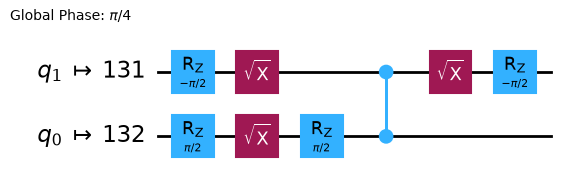

In [9]:
# Transpile the circuit and optimize for running on the quantum computer selected
# Step 2: Transpile
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager

target = backend.target
pm = generate_preset_pass_manager(target=target, optimization_level=3)
qc_isa = pm.run(qc)
obs_isa = obs.apply_layout(layout=qc_isa.layout)

qc_isa.draw("mpl")

#### Execute

In the Execute step, we'll load `Estimator`, then send the circuit plus the list of observables that we want it to estimate to the quantum computer.



In [10]:
# Load the Runtime primitive and session
from qiskit_ibm_runtime import EstimatorV2 as Estimator

estimator = Estimator(mode=backend)

In [11]:
# Load the backend sampler

# noise_model = NoiseModel.from_backend(backend)

# Use Aer simulator in Estimator
# estimator_sim = BackendEstimatorV2(backend=backend_sim)

# Alternatively, load a fake backend with generic properties and define a simulator.
# backend_gen = GenericBackendV2(num_qubits=18)
# estimator_gen = BackendEstimatorV2(backend=backend_gen)

In [12]:
pubs = [(qc_isa, obs_isa)]
job = estimator.run([[qc_isa, obs_isa]])
res = job.result()

# Uncomment lines below to run the job on the Aer simulator with noise model from real backend
# job = estimator_sim.run([[qc_isa,obs_isa]])
# res=job.result()

#### Post-process

Finally, in the post-processing step, we simply print the energy calculated behind the scenes by `Estimator`.



In [13]:
print(res[0].data.evs)

-0.9900104958876071


This is the energy of our state!

## Conclusion

In this lesson, we learned how to prepare a simple two-qubit quantum state representing two interacting spins. We saw how to use `Sampler` to observe the distribution of measurement outcomes and how to use `Estimator` to calculate the energy of the state according to the Hamiltonian. Along the way, we saw how the Hamiltonian encodes the interactions between spins and the effects of an external field, and how different states can have different energies.

### Extension to many spins

So far, we have only looked at two spins, which is simple enough to analyze by hand. In real physical systems, such as in a magnet or other complex material, there are often many interacting spins. When the number of spins increases, the Hamiltonian becomes more complex and finding the lowest-energy state becomes much harder. This is where quantum computers can help: by preparing different states and estimating their energies, we can explore low-energy configurations more efficiently than classical computers for large systems.

A natural extension of this experiment would be to increase the number of qubits to represent more spins and adjust the way the spins are prepared to try to find the lowest-energy state. This approach is the essence of variational methods, which you can learn about in the [Variational Quantum Algorithms](/learning/courses/variational-algorithm-design) course.

There are also other quantum approaches to studying ground-state energies that go beyond variational techniques. These methods are not covered here, but are introduced in the [Quantum Diagonalization Algorithms](/learning/courses/quantum-diagonalization-algorithms) course if you're interested in learning more.

#### Learning objective

Go back to the beginning of Experiment 2 and retry it with a different superposition state. Can you find a state with even lower energy than the one we used?



© IBM Corp., 2017-2026